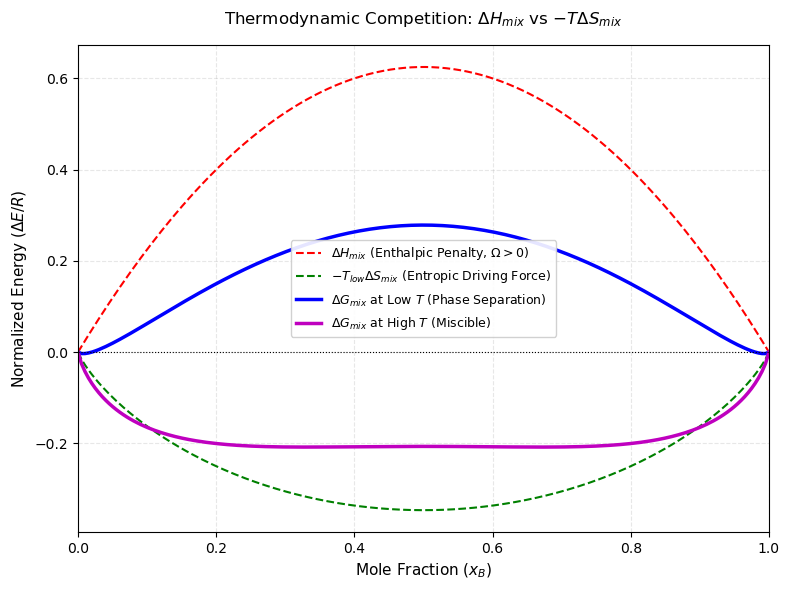

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define composition range (Mole fraction of component B)
# We start slightly above 0 and below 1 to avoid natural log of zero errors

xB = np.linspace(1e-5, 1 - 1e-5, 200)

# 2. Ideal Entropy of Mixing term (-T * \Delta S_mix)
# \Delta S_mix = -R * [xB*ln(xB) + (1-xB)*ln(1-xB)]
# We normalize by R for a cleaner energetic scale
dS_mix = -(xB * np.log(xB) + (1 - xB) * np.log(1 - xB))

# 3. Regular Solution Enthalpy of Mixing (\Delta H_mix)
# \Delta H_mix = \Omega * xB * (1 - xB)
# Setting \Omega = 2.5 creates a positive (endothermic) mixing penalty
omega = 2.5
dH_mix = omega * xB * (1 - xB)

# 4. Calculate Gibbs Free Energy (\Delta G = \Delta H - T\Delta S)
# Low Temperature: Enthalpy wins in the middle, creating a local maximum (unstable/phase separation)
T_low = 0.5
dG_low = dH_mix - T_low * dS_mix

# High Temperature: Entropy wins completely, creating a single downward well (fully miscible)
T_high = 1.2
dG_high = dH_mix - T_high * dS_mix

# 5. Plotting the results
plt.figure(figsize=(8, 6), dpi=100)

# Plot individual components
plt.plot(xB, dH_mix, 'r--', linewidth=1.5, 
         label=r'$\Delta H_{mix}$ (Enthalpic Penalty, $\Omega > 0$)')
plt.plot(xB, -T_low * dS_mix, 'g--', linewidth=1.5, 
         label=r'$-T_{low}\Delta S_{mix}$ (Entropic Driving Force)')

# Plot resulting Gibbs free energy curves
plt.plot(xB, dG_low, 'b-', linewidth=2.5, 
         label=r'$\Delta G_{mix}$ at Low $T$ (Phase Separation)')
plt.plot(xB, dG_high, 'm-', linewidth=2.5, 
         label=r'$\Delta G_{mix}$ at High $T$ (Miscible)')

# Formatting graph aesthetics
plt.axhline(0, color='black', linewidth=0.8, linestyle=':')
plt.title(r'Thermodynamic Competition: $\Delta H_{mix}$ vs $-T\Delta S_{mix}$', fontsize=12, pad=15)
plt.xlabel(r'Mole Fraction ($x_B$)', fontsize=11)
plt.ylabel(r'Normalized Energy ($\Delta E / R$)', fontsize=11)
plt.xlim(0, 1)
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(loc='best', fontsize=9, framealpha=0.9)

# Show the plot
plt.tight_layout()
plt.show()
